In [1]:
!pwd

/mnt/c/Users/vvasileiou/Desktop/test_lncAPNet/Pilot_3_TCGA_Breast/notebooks/Post-hoc_Analysis


In [2]:
import pandas as pd
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import math
from lifelines import CoxPHFitter

In [3]:
import pandas as pd
import numpy as np
from lifelines import CoxPHFitter

# ==========================================
# 1. LOAD DATASET
# ==========================================
df = pd.read_csv('../../../data/TCGA_Breast/metadata.csv')

# ==========================================
# 2. ENGINEER OVERALL SURVIVAL OUTCOMES
# ==========================================
# Map text status to binary event indicator (Dead = 1, Alive = 0)
df['OS_Event'] = df['vital_status'].apply(lambda x: 1 if str(x).lower() == 'dead' else 0)

# Track time: use days_to_death if dead, otherwise use days_to_last_follow_up
df['OS_Time'] = np.where(df['OS_Event'] == 1, df['days_to_death'], df['days_to_last_follow_up'])

# Clean target timelines: drop missing (NaN), zero, or negative time tracking
df = df.dropna(subset=['OS_Time', 'OS_Event'])
df = df[df['OS_Time'] > 0]

# ==========================================
# 3. SELECT INDEPENDENT COVARIATES
# ==========================================
# Select distinct clinical variables (omitting IDs and highly correlated age copies)
categorical_covariates = [
    'gender', 'race', 'ethnicity', 'ajcc_pathologic_stage', 
    'ajcc_pathologic_t', 'ajcc_pathologic_n', 'ajcc_pathologic_m',
    'prior_malignancy', 'paper_BRCA_Subtype_PAM50'
]
numerical_covariates = [
    'age_at_diagnosis', 'initial_weight'
]

# Keep only the cleaned tracking data + selected covariates
columns_to_keep = ['OS_Time', 'OS_Event'] + categorical_covariates + numerical_covariates
analysis_df = df[columns_to_keep].dropna()

# ==========================================
# 4. ONE-HOT ENCODING & SINGULARITY PREVENTION
# ==========================================
# Convert strings to binary dummy variables
encoded_df = pd.get_dummies(analysis_df, columns=categorical_covariates, drop_first=True)
encoded_df = encoded_df.astype(float)

# Drop features with <1% variance to prevent the "Complete Separation" crash
variance_threshold = 0.01
low_variance_cols = encoded_df.columns[encoded_df.var() < variance_threshold]
low_variance_cols = [col for col in low_variance_cols if col not in ['OS_Time', 'OS_Event']]

if low_variance_cols:
    print(f"Dropping {len(low_variance_cols)} low-variance columns to stabilize matrix math:")
    print(low_variance_cols, "\n")
    encoded_df = encoded_df.drop(columns=low_variance_cols)

# ==========================================
# 5. FIT REGRESSION MODEL WITH L2 PENALIZER
# ==========================================
# The penalizer parameter acts as a safety ridge to resolve high-collinearity errors
cph = CoxPHFitter(penalizer=0.1)
cph.fit(encoded_df, duration_col='OS_Time', event_col='OS_Event')

# ==========================================
# 6. OUTPUT SUMMARY RESULTS
# ==========================================
# Print the full lifelines statistical summary table
cph.print_summary()

# Extract and filter to show only statistically significant covariates
print("\n" + "="*50)
print("COVARIATES SIGNIFICANTLY CORRELATED WITH SURVIVAL (p < 0.05):")
print("="*50)
results = cph.summary[['coef', 'exp(coef)', 'p']]
results.columns = ['Coefficient', 'Hazard_Ratio', 'p_value']
significant_results = results[results['p_value'] < 0.05]

if not significant_results.empty:
    print(significant_results)
else:
    print("No individual covariates met the p < 0.05 threshold with the current penalizer setting.")


Dropping 10 low-variance columns to stabilize matrix math:
['ajcc_pathologic_stage_Stage II', 'ajcc_pathologic_stage_Stage IIIB', 'ajcc_pathologic_t_T1a', 'ajcc_pathologic_t_T4', 'ajcc_pathologic_t_T4b', 'ajcc_pathologic_n_N0 (mol+)', 'ajcc_pathologic_n_N1c', 'ajcc_pathologic_n_N3b', 'ajcc_pathologic_n_NX', 'ajcc_pathologic_m_cM0 (i+)'] 



<lifelines.CoxPHFitter: fitted with 427 total observations, 393 right-censored observations>
             duration col = 'OS_Time'
                event col = 'OS_Event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 427
number of events observed = 34
   partial log-likelihood = -153.00
         time fit was run = 2026-06-02 11:23:32 UTC

---
                                   coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
covariate                                                                                                                                
age_at_diagnosis                   0.00       1.00       0.00             0.00             0.00                 1.00                 1.00
initial_weight                     0.00       1.00       0.00            -0.00             0.00                 1.00                 1.00
race_black or african american     0.05       1.05       0.33            -0.59             0.69                 0.55                 1.99
race_not reported                 -0.17       0.84       0.80            -1.73             1.39                 0.18                 4.03
race_white                        -0.06       0.94       0.30            -0.65             0.53                 0.52                 1.71
ethnicity_hispanic or latino      -0.51       0.60       0.65            -1.79             0.77                 0.17                 2.15
ethnicity_not hispanic or latino   0.40       1.49       0.36            -0.30             1.10                 0.74                 3.02
ethnicity_not reported            -0.32       0.73       0.42            -1.14             0.50                 0.32                 1.65
ajcc_pathologic_stage_Stage IA    -0.21       0.81       0.44            -1.07             0.64                 0.34                 1.90
ajcc_pathologic_stage_Stage IB    -0.46       0.63       1.20            -2.80             1.88                 0.06                 6.57
ajcc_pathologic_stage_Stage IIA    0.25       1.28       0.26            -0.26             0.76                 0.77                 2.14
ajcc_pathologic_stage_Stage IIB   -0.05       0.95       0.29            -0.62             0.51                 0.54                 1.67
ajcc_pathologic_stage_Stage IIIA   0.08       1.08       0.36            -0.63             0.79                 0.53                 2.20
ajcc_pathologic_stage_Stage IIIC   0.30       1.35       0.56            -0.80             1.39                 0.45                 4.03
ajcc_pathologic_t_T1b             -0.49       0.61       0.93            -2.31             1.33                 0.10                 3.78
ajcc_pathologic_t_T1c             -0.13       0.87       0.30            -0.72             0.45                 0.49                 1.56
ajcc_pathologic_t_T2              -0.12       0.89       0.25            -0.62             0.37                 0.54                 1.45
ajcc_pathologic_t_T3              -0.04       0.96       0.36            -0.73             0.66                 0.48                 1.93
ajcc_pathologic_n_N0 (i+)         -0.08       0.92       0.65            -1.35             1.18                 0.26                 3.27
ajcc_pathologic_n_N0 (i-)         -0.40       0.67       0.31            -1.02             0.22                 0.36                 1.24
ajcc_pathologic_n_N1               0.06       1.07       0.41            -0.74             0.86                 0.48                 2.37
ajcc_pathologic_n_N1a             -0.28       0.76       0.36            -0.98             0.43                 0.38                 1.53
ajcc_pathologic_n_N1b              1.00       2.73       0.48             0.07             1.94                 1.07                 6.96
ajcc_pathologic_n_N1mi            -0.01       0.99       0.61            -1.20             1.19                 0.30        


COVARIATES SIGNIFICANTLY CORRELATED WITH SURVIVAL (p < 0.05):
                       Coefficient  Hazard_Ratio   p_value
covariate                                                 
age_at_diagnosis          0.000059      1.000059  0.021937
ajcc_pathologic_n_N1b     1.003496      2.727801  0.035660


Gene GATA3-AS1_NC Baseline Cohort Size: 436 samples
Gene AFAP1-AS1_NC Baseline Cohort Size: 436 samples
Gene DSCAM-AS1_NC Baseline Cohort Size: 436 samples


/home/vasileioubill95/miniconda3/envs/lncAPNet/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Successfully generated and saved 3x2 panel plot to: ../../figures/etc.png


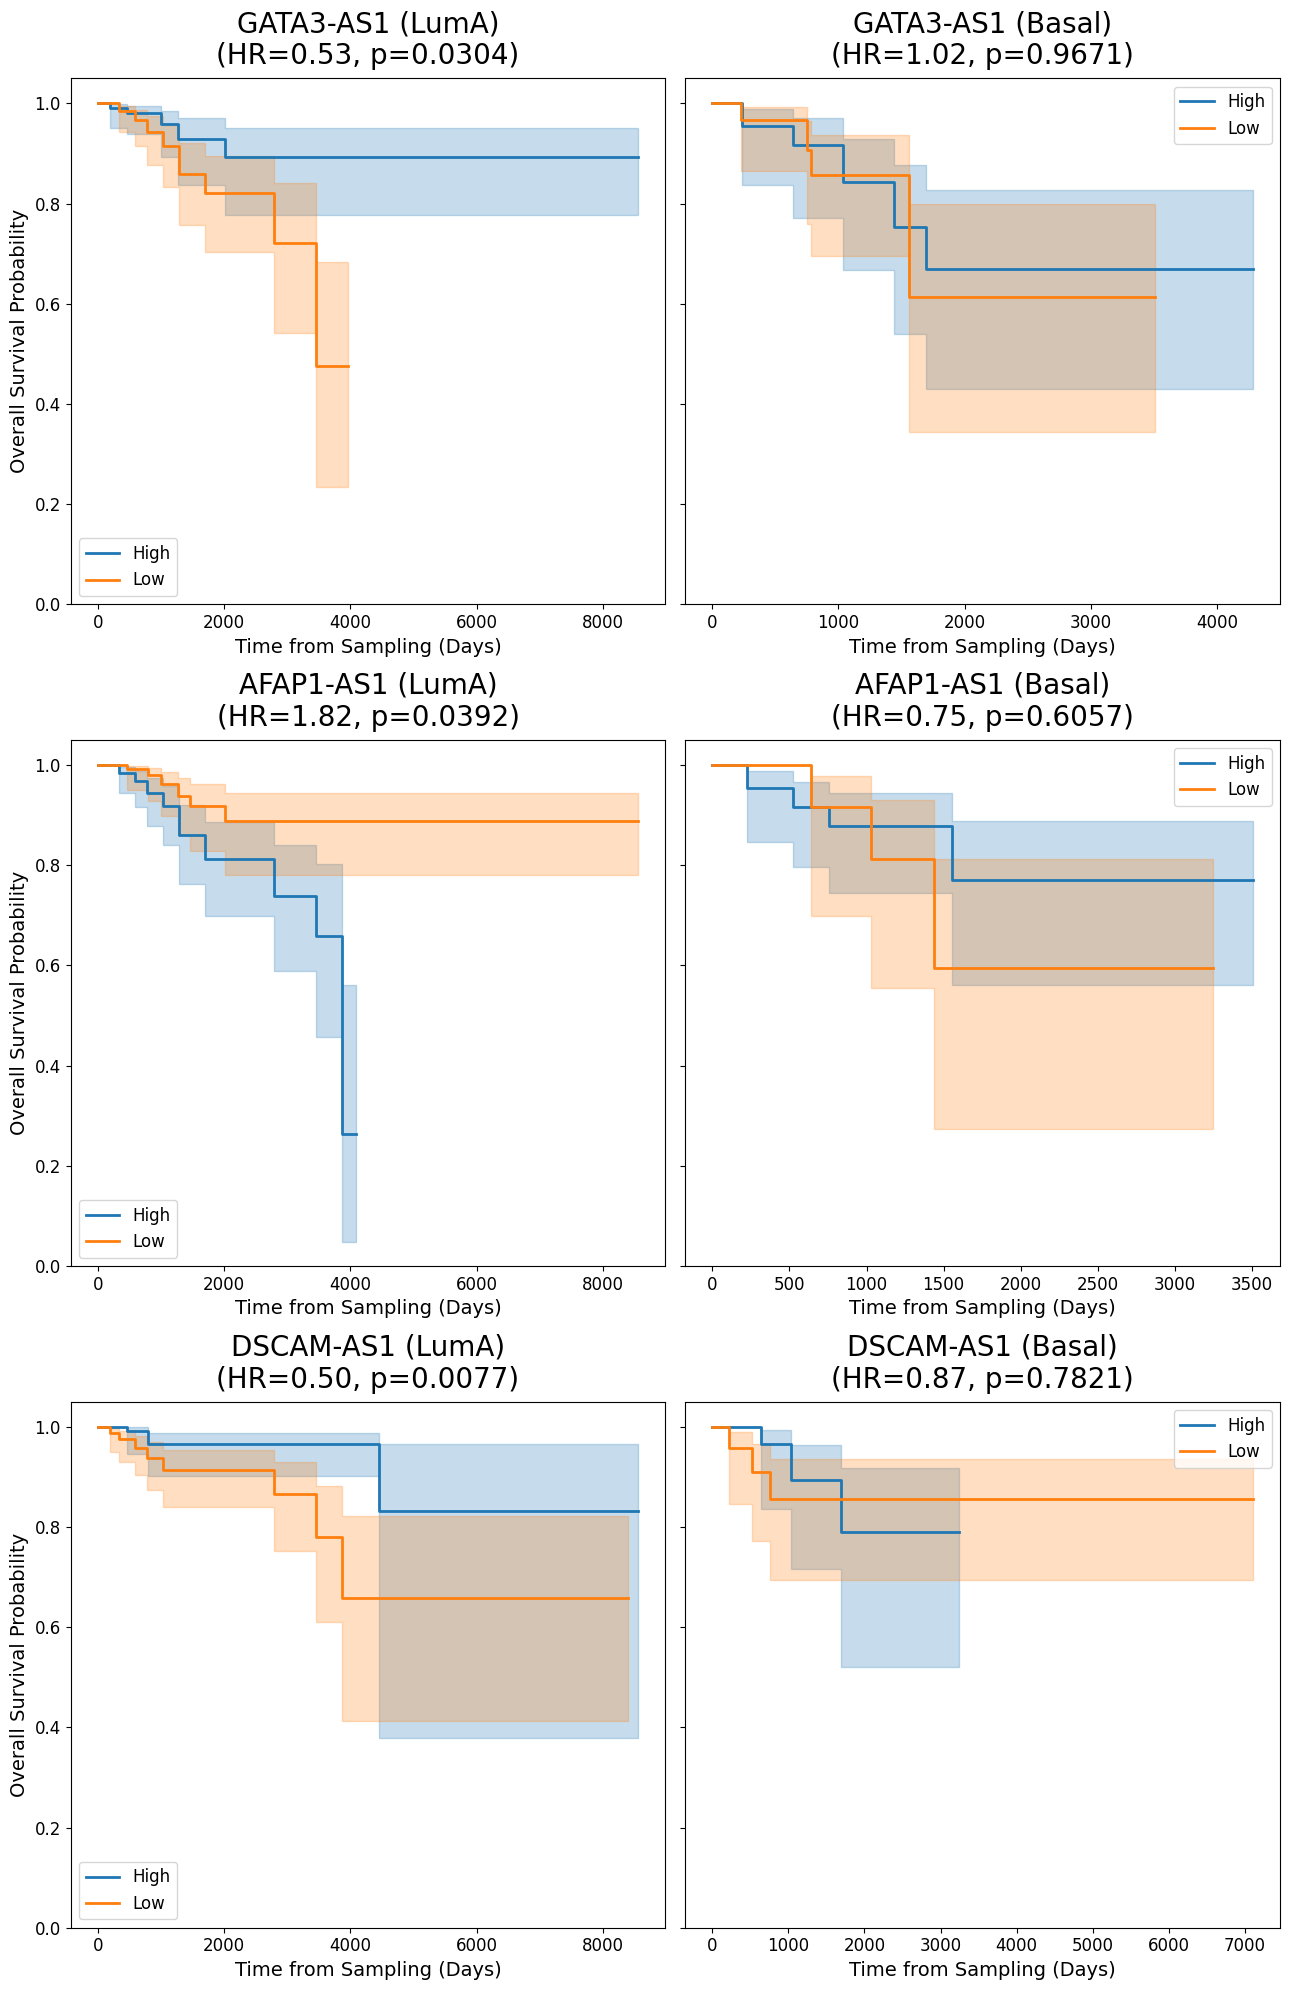

In [7]:
import os
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lifelines import KaplanMeierFitter, CoxPHFitter
import statsmodels.formula.api as smf

# Suppress the expected non-integer propensity score warning from lifelines
warnings.filterwarnings("ignore", message="It looks like your weights are not integers")

# Configuration parameters
target_genes = ["GATA3-AS1_NC", "AFAP1-AS1_NC", "DSCAM-AS1_NC"]
subtype_col = "paper_BRCA_Subtype_PAM50"
raw_node_col = "ajcc_pathologic_n"  
subtypes_to_analyze = ["LumA", "Basal"]

# Ensure output directory exists
output_dir = "../../figures"
os.makedirs(output_dir, exist_ok=True)

# ==========================================
# 1. LOAD YOUR FILES
# ==========================================
df_meta = pd.read_csv("../../../data/TCGA_Breast/metadata.csv", sep=None, engine='python')
df_expr_raw = pd.read_csv("../../../data/TCGA_Breast/activity_matrix.csv", sep=None, engine='python')

df_meta.columns = df_meta.columns.str.strip()
df_expr_raw.columns = df_expr_raw.columns.str.strip()


# ==========================================
# 2. TRANSPOSE THE EXPRESSION MATRIX
# ==========================================
gene_col_name = df_expr_raw.columns[0]  
df_expr_raw[gene_col_name] = df_expr_raw[gene_col_name].astype(str).str.strip()

df_expr = df_expr_raw.set_index(gene_col_name).T
df_expr.columns.name = None
df_expr = df_expr.reset_index().rename(columns={'index': 'Barcode_Key'})


# ==========================================
# 3. DEFINE THE SURVIVAL TARGETS
# ==========================================
def calculate_survival_time(row):
    status = str(row["vital_status"]).strip().lower()
    if status == "dead":
        return pd.to_numeric(row["days_to_death"], errors="coerce")
    elif status == "alive":
        return pd.to_numeric(row["days_to_last_follow_up"], errors="coerce")
    return np.nan


df_meta["Time"] = df_meta.apply(calculate_survival_time, axis=1)
df_meta["Event"] = (
    df_meta["vital_status"].astype(str).str.strip().str.lower() == "dead"
).astype(int)


# ==========================================
# 4. MERGE METADATA AND EXPRESSION
# ==========================================
df_meta["Merge_Key"] = df_meta["barcode"].astype(str).str.strip()
df_expr["Merge_Key"] = df_expr["Barcode_Key"].astype(str).str.strip()

df_master_raw = pd.merge(df_meta, df_expr, on="Merge_Key", how="inner")


# ==========================================
# 5. GENERAL DATA CLEANING & STRING VECTORIZATION
# ==========================================
# Clean raw text spaces & extract the specific N1b indicator
df_master_raw[raw_node_col] = df_master_raw[raw_node_col].astype(str).str.strip()
df_master_raw["ajcc_pathologic_n_N1b"] = np.where(df_master_raw[raw_node_col] == "N1b", 1, 0)

df_master_raw["Time"] = pd.to_numeric(df_master_raw["Time"])
df_master_raw["Event"] = pd.to_numeric(df_master_raw["Event"])
df_master_raw["age_at_diagnosis"] = pd.to_numeric(df_master_raw["age_at_diagnosis"])
df_master_raw[subtype_col] = df_master_raw[subtype_col].astype(str).str.strip()


# ==========================================
# 6. INITIALIZE 3X2 MULTIPANEL CANVAS
# ==========================================
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(13, 20), sharey=True)
kmf = KaplanMeierFitter()


# ==========================================
# 7. MULTI-GENE & SUBTYPE PIPELINE LOOP
# ==========================================
for row_idx, target_gene in enumerate(target_genes):
    
    # Ensure numerical values for current target gene
    df_master = df_master_raw.dropna(subset=["Time", "Event", "age_at_diagnosis", target_gene, subtype_col, raw_node_col]).copy()
    df_master[target_gene] = pd.to_numeric(df_master[target_gene], errors='coerce')
    df_master = df_master.dropna(subset=[target_gene])
    df_master = df_master[df_master["Time"] >= 0]
    
    print(f"Gene {target_gene} Baseline Cohort Size: {len(df_master)} samples")

    for col_idx, subtype in enumerate(subtypes_to_analyze):
        ax = axes[row_idx, col_idx]
        
        # Isolate current subtype context group
        df_sub = df_master[df_master[subtype_col] == subtype].copy()
        
        if len(df_sub) == 0:
            print(f"Warning: Subtype '{subtype}' not found for {target_gene}. Skipping panel.")
            ax.axis('off')
            continue

        # Calculate IQR thresholds specific to this subtype group
        q1 = df_sub[target_gene].quantile(0.25)
        q3 = df_sub[target_gene].quantile(0.75)

        # Separate contrasting expression groups
        low_grp = df_sub[df_sub[target_gene] < q1].copy()
        high_grp = df_sub[df_sub[target_gene] > q3].copy()

        low_grp["Is_High_Expression"] = 0
        high_grp["Is_High_Expression"] = 1

        df_cox_input = pd.concat([low_grp, high_grp]).reset_index(drop=True)

        # Handle tiny sample cohorts safely
        if len(low_grp) < 3 or len(high_grp) < 3:
            print(f"Warning: Not enough data points in split tiers for {target_gene} ({subtype}). Skipping.")
            ax.axis('off')
            continue

        # Propensity model formula targets both age and our newly engineered binary N1b feature
        propensity_formula = "Is_High_Expression ~ age_at_diagnosis + ajcc_pathologic_n_N1b"
        propensity_model = smf.logit(propensity_formula, data=df_cox_input).fit(disp=0)
        df_cox_input["Propensity_Score"] = propensity_model.predict(df_cox_input[["age_at_diagnosis", "ajcc_pathologic_n_N1b"]])
        df_cox_input["Propensity_Score"] = df_cox_input["Propensity_Score"].clip(0.01, 0.99)

        df_cox_input["IPTW_Weight"] = np.where(
            df_cox_input["Is_High_Expression"] == 1,
            1.0 / df_cox_input["Propensity_Score"],
            1.0 / (1.0 - df_cox_input["Propensity_Score"])
        )

        high_grp_weighted = df_cox_input[df_cox_input["Is_High_Expression"] == 1]
        low_grp_weighted = df_cox_input[df_cox_input["Is_High_Expression"] == 0]

        # Multivariable Cox Model adjusting for both clinical features
        cph = CoxPHFitter(penalizer=0.05)
        cox_features = ["Time", "Event", "Is_High_Expression", "age_at_diagnosis", "ajcc_pathologic_n_N1b"]
        cph.fit(df_cox_input[cox_features], duration_col="Time", event_col="Event", robust=True)

        hazard_ratio = cph.hazard_ratios_["Is_High_Expression"]
        adjusted_p_value = cph.summary.loc["Is_High_Expression", "p"]

        # Formatting scientific notations for tiny p-values
        if adjusted_p_value >= 0.001:
            pval_str = f"{adjusted_p_value:.4f}"
        else:
            pval_str = f"{adjusted_p_value:.1e}".replace("e-0", "e-").replace("e", "×10")
        hr_str = f"{hazard_ratio:.2f}"

        # Generate Adjusted Kaplan-Meier plots mapping IPTW weights
        # High -> Standard Blue with shaded confidence intervals
        kmf.fit(durations=high_grp_weighted["Time"], 
                event_observed=high_grp_weighted["Event"], 
                weights=high_grp_weighted["IPTW_Weight"])
        kmf.plot_survival_function(ci_show=True, color="#1f77b4", linewidth=2, ax=ax, label="High")

        # Low -> Standard Orange with shaded confidence intervals
        kmf.fit(durations=low_grp_weighted["Time"], 
                event_observed=low_grp_weighted["Event"], 
                weights=low_grp_weighted["IPTW_Weight"])
        kmf.plot_survival_function(ci_show=True, color="#ff7f0e", linewidth=2, ax=ax, label="Low")

        # Clean header mapping (e.g., "GATA3-AS1 (LumA)")
        gene_clean = target_gene.replace("_NC", "").replace("_SIG", "")
        ax.set_title(f"{gene_clean} ({subtype})\n(HR={hr_str}, p={pval_str})", fontsize=20, pad=10)

        # Label styling matching reference template dimensions
        ax.set_xlabel("Time from Sampling (Days)", fontsize=14)
        ax.set_ylabel("Overall Survival Probability", fontsize=14)
        ax.tick_params(axis='both', labelsize=12)
        ax.legend(fontsize=12, loc="lower left" if col_idx == 0 else "upper right")
        ax.set_ylim(0, 1.05)
        ax.grid(False)  

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "etc.png"), dpi=300, bbox_inches='tight')
print(f"Successfully generated and saved 3x2 panel plot to: {os.path.join(output_dir, 'etc.png')}")
